In [2]:
import numpy as np
import matplotlib.pyplot as plt

def spatial_grid(L, Nx):
    
    return np.linspace(-L/2, L/2, Nx, endpoint=False)


def thickness_profile(x, Lambda, duty, d0, h):
    
    phase_in_period = (x % Lambda) / Lambda
    d = d0 + h * (phase_in_period < duty).astype(float)
    return d


def phase_signal(d, n, lam):
    
    k = 2*np.pi/lam
    return n * k * d


def plot_signal(x, f):
    
    plt.figure()
    plt.plot(x*1e6, f)
    plt.xlabel("x (µm)")
    plt.ylabel("f(x) = n k d(x) (rad)")
    plt.title("Phase Signal")
    plt.grid(True)
    plt.show()

In [3]:
# spatial parameters
L = 10e-6
Nx = 512

# optical parameters
lam = 630e-9
n = 1.0

# grating parameters
Lambda = 2e-6
duty = 0.75
d0 = 100e-9
h = 200e-9


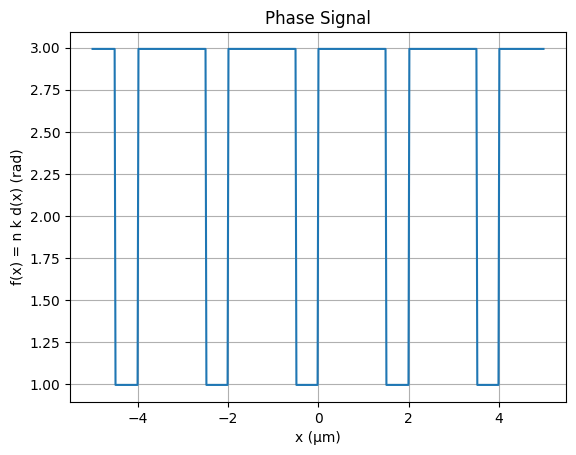

In [4]:
x = spatial_grid(L, Nx)

d = thickness_profile(x, Lambda, duty, d0, h)

f = phase_signal(d, n, lam)

plot_signal(x, f)

In [5]:
import numpy as np

def phi_from_f(f):
    alpha = np.sum(f)
    phi = np.sqrt(f / alpha)
    return phi, alpha

In [6]:
phi, alpha = phi_from_f(f)

print("alpha =", alpha)
print("check normalization =", np.sum(phi**2))
print('phase =', phi)

alpha = 1278.5783434609884
check normalization = 1.0
phase = [0.04837451 0.04837451 0.04837451 0.04837451 0.04837451 0.04837451
 0.04837451 0.04837451 0.04837451 0.04837451 0.04837451 0.04837451
 0.04837451 0.04837451 0.04837451 0.04837451 0.04837451 0.04837451
 0.04837451 0.04837451 0.04837451 0.04837451 0.04837451 0.04837451
 0.04837451 0.04837451 0.02792904 0.02792904 0.02792904 0.02792904
 0.02792904 0.02792904 0.02792904 0.02792904 0.02792904 0.02792904
 0.02792904 0.02792904 0.02792904 0.02792904 0.02792904 0.02792904
 0.02792904 0.02792904 0.02792904 0.02792904 0.02792904 0.02792904
 0.02792904 0.02792904 0.02792904 0.02792904 0.04837451 0.04837451
 0.04837451 0.04837451 0.04837451 0.04837451 0.04837451 0.04837451
 0.04837451 0.04837451 0.04837451 0.04837451 0.04837451 0.04837451
 0.04837451 0.04837451 0.04837451 0.04837451 0.04837451 0.04837451
 0.04837451 0.04837451 0.04837451 0.04837451 0.04837451 0.04837451
 0.04837451 0.04837451 0.04837451 0.04837451 0.04837451 0.04837451
 

/tmp/ipykernel_3302218/1579396002.py:28: DeprecationWarning: The return type of saved statevectors has been changed from a `numpy.ndarray` to a `qiskit.quantum_info.Statevector` as of qiskit-aer 0.10. Accessing numpy array attributes is deprecated and will result in an error in a future release. To continue using saved result objects as arrays you can explicitly cast them using  `np.asarray(object)`.
  print("Prepared statevector length:", len(sv))


Prepared statevector length: 512
Circuit depth: 1


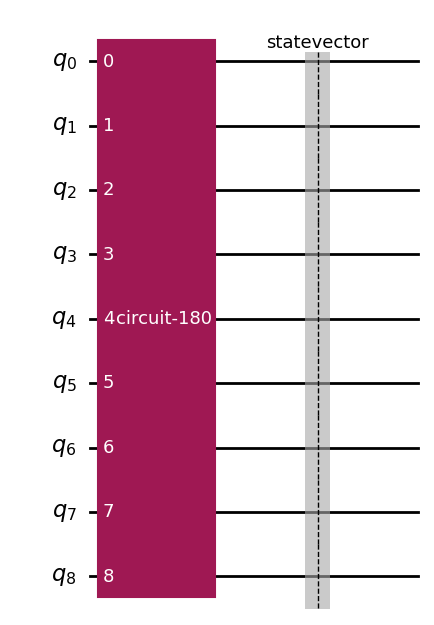

In [7]:
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_mps_initializer.datatypes import QuantumState

# phi must have length 2^n
phi = np.asarray(phi, dtype=float)
N = len(phi)
n = int(np.log2(N))


number_of_layers = 2

# build MPS initializer for |phi>
phi_state = QuantumState.from_dense_data(data=phi, normalize=True)
U_phi = phi_state.generate_mps_initializer_circuit(number_of_layers=number_of_layers)

# single-register circuit
qc = QuantumCircuit(n, name="prep_phi")
qc.append(U_phi, range(n))

# (optional) simulate to confirm statevector
sim = AerSimulator(method="statevector")
qc.save_statevector()
res = sim.run(transpile(qc, sim)).result()
sv = res.get_statevector(qc)

print("Prepared statevector length:", len(sv))
print("Circuit depth:", qc.depth())
qc.draw("mpl")

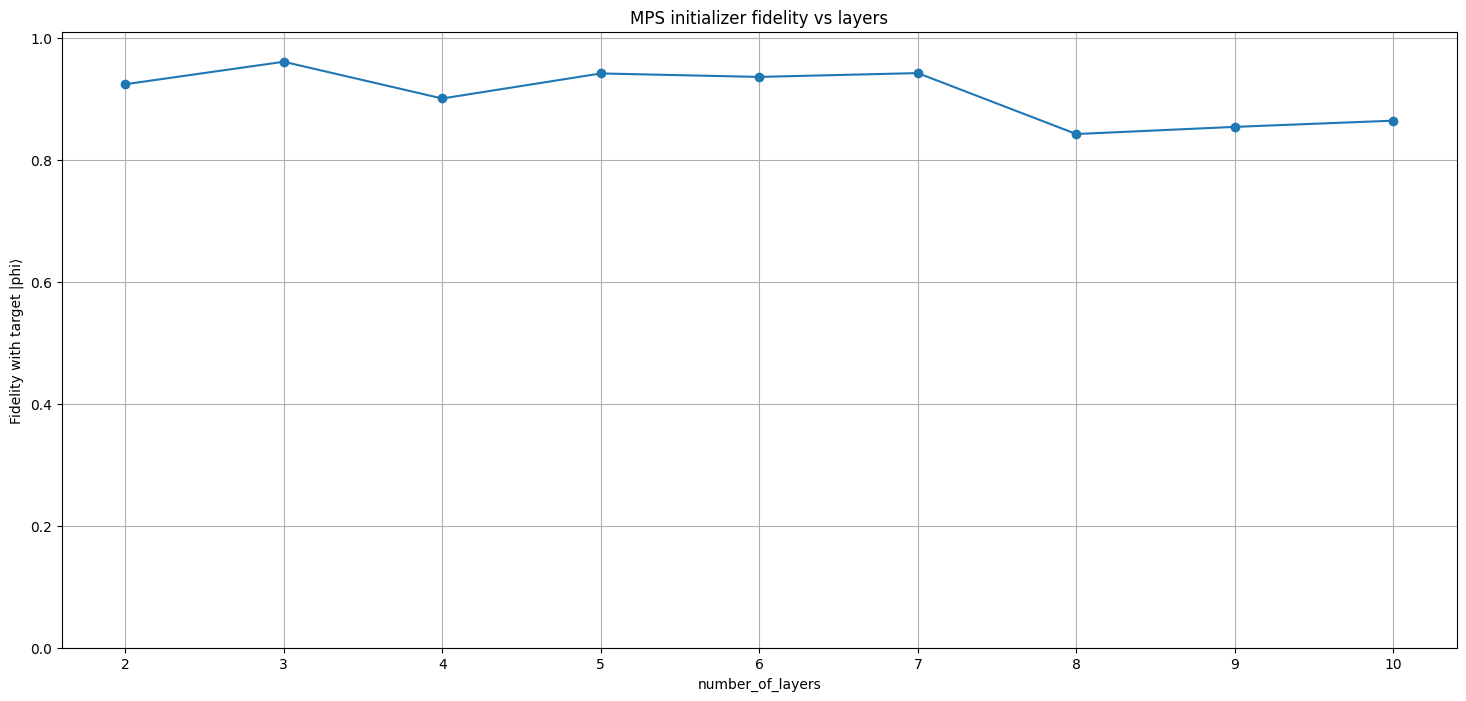

[(2, 0.923660187737971), (3, 0.96051530616777), (4, 0.9002982522095512), (5, 0.9413536771325287), (6, 0.9356703477893766), (7, 0.9419394011429235), (8, 0.8420232481657102), (9, 0.8537614660821565), (10, 0.8639515674642128)]


In [8]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_mps_initializer.datatypes import QuantumState
from qiskit.quantum_info import state_fidelity


phi = np.asarray(phi, dtype=float)
phi = phi / np.linalg.norm(phi)

N = len(phi)
n = int(np.log2(N))


# simulator
sim = AerSimulator(method="statevector")


layers_list = list(range(2, 11))
fidelities = []

for L in layers_list:
    # build initializer for this number of layers
    phi_state = QuantumState.from_dense_data(data=phi, normalize=False)
    U_phi = phi_state.generate_mps_initializer_circuit(number_of_layers=L)

    # prepare circuit
    qc = QuantumCircuit(n)
    qc.append(U_phi, range(n))
    qc.save_statevector()

    # simulate
    result = sim.run(transpile(qc, sim)).result()
    prepared = np.array(result.get_statevector(qc), dtype=complex)

    # fidelity with target (pure state)
    F = state_fidelity(prepared, phi.astype(complex))
    fidelities.append(F)

#plot
plt.figure(figsize=(18,8))
plt.plot(layers_list, fidelities, marker="o")
plt.xlabel("number_of_layers")
plt.ylabel("Fidelity with target |phi⟩")
plt.title("MPS initializer fidelity vs layers")
plt.grid(True)
plt.ylim(0, 1.01)
plt.show()

print(list(zip(layers_list, fidelities)))

Fidelity for L=5: 0.94135368


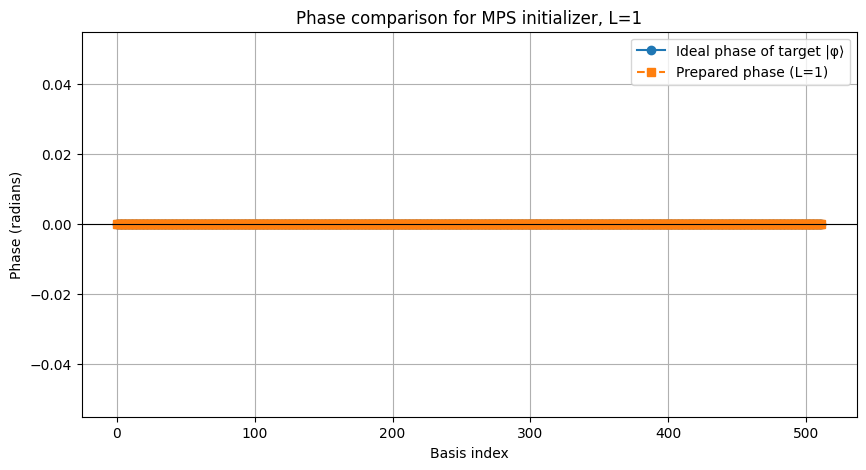

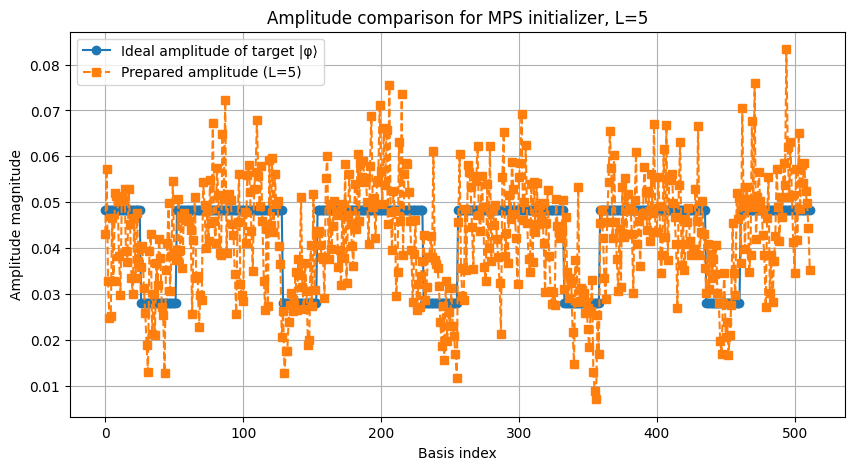

In [14]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_mps_initializer.datatypes import QuantumState
from qiskit.quantum_info import state_fidelity

# ----------------------------
# input target state phi
# ----------------------------
phi = np.asarray(phi, dtype=complex)   # can also be float, but complex is safer
phi = phi / np.linalg.norm(phi)

N = len(phi)
n = int(np.log2(N))
assert 2**n == N, "Length of phi must be a power of 2."

# ----------------------------
# choose one number of layers
# ----------------------------
number_of_layers = 5  # change this to any layer you want to inspect

# simulator
sim = AerSimulator(method="statevector")

# ----------------------------
# build MPS initializer
# ----------------------------
phi_state = QuantumState.from_dense_data(data=phi, normalize=False)
U_phi = phi_state.generate_mps_initializer_circuit(number_of_layers=number_of_layers)

# prepare circuit
qc = QuantumCircuit(n)
qc.append(U_phi, range(n))
qc.save_statevector()

# simulate
result = sim.run(transpile(qc, sim)).result()
vec_sim = np.array(result.get_statevector(qc), dtype=complex)

# ----------------------------
# fidelity
# ----------------------------
F = state_fidelity(vec_sim, phi)
print(f"Fidelity for L={number_of_layers}: {F:.8f}")

# ----------------------------
# align global phase
# ----------------------------
global_phase = np.angle(np.vdot(phi, vec_sim))
vec_sim_aligned = vec_sim * np.exp(-1j * global_phase)

# ----------------------------
# amplitudes and phases
# ----------------------------
amps_ideal = np.abs(phi)
amps_sim = np.abs(vec_sim_aligned)

phases_ideal = np.unwrap(np.angle(phi))
phases_sim = np.unwrap(np.angle(vec_sim_aligned))

# ----------------------------
# Phase comparison plot
# ----------------------------
plt.figure(figsize=(10, 5))
plt.plot(range(N), phases_ideal, 'o-', label="Ideal phase of target |φ⟩")
plt.plot(range(N), phases_sim, 's--', label=f"Prepared phase (L={L_example})")
plt.axhline(0, color='black', linewidth=0.8)
plt.xlabel("Basis index")
plt.ylabel("Phase (radians)")
plt.title(f"Phase comparison for MPS initializer, L={L_example}")
plt.legend()
plt.grid(True)
plt.show()

# ----------------------------
# Amplitude comparison plot
# ----------------------------
plt.figure(figsize=(10, 5))
plt.plot(range(N), amps_ideal, 'o-', label="Ideal amplitude of target |φ⟩")
plt.plot(range(N), amps_sim, 's--', label=f"Prepared amplitude (L={number_of_layers})")
plt.xlabel("Basis index")
plt.ylabel("Amplitude magnitude")
plt.title(f"Amplitude comparison for MPS initializer, L={number_of_layers}")
plt.legend()
plt.grid(True)
plt.show()

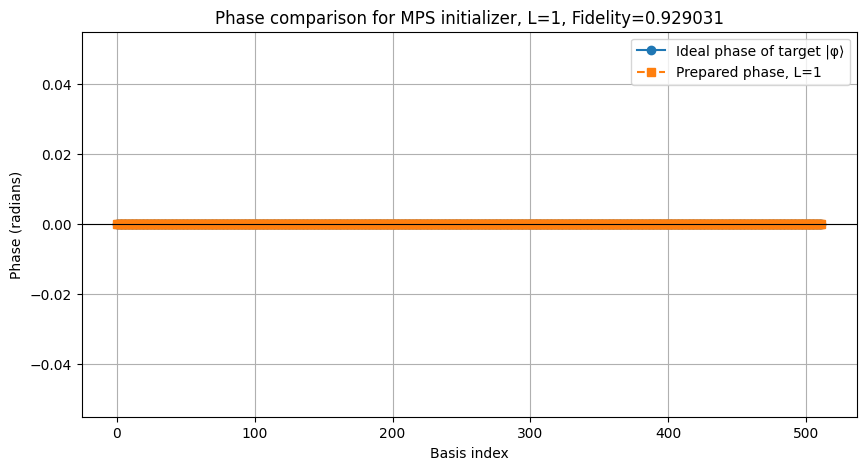

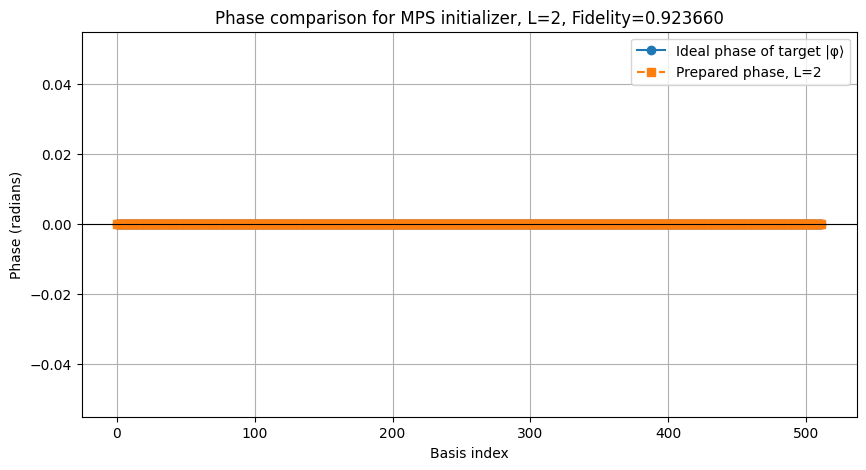

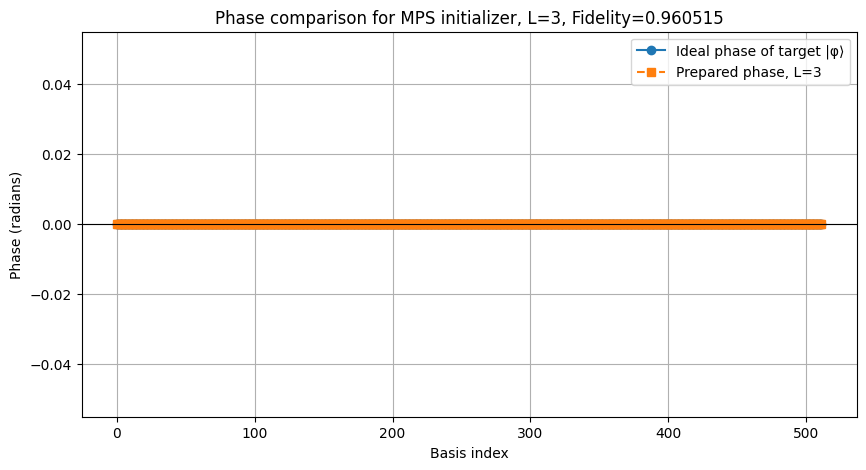

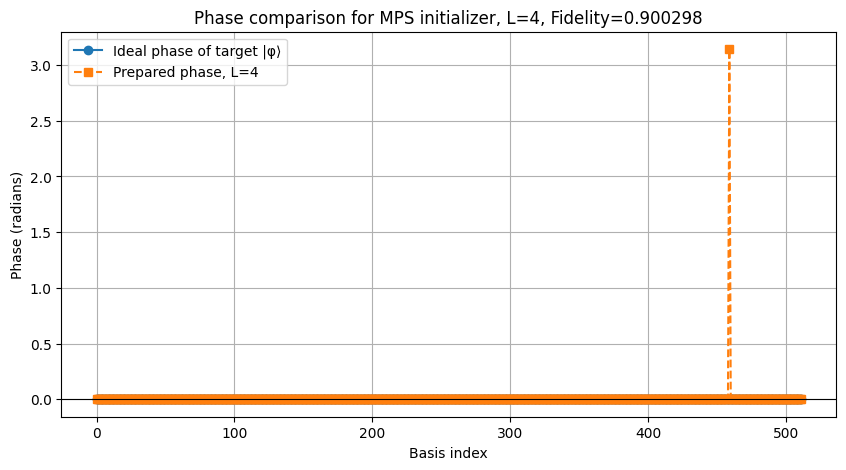

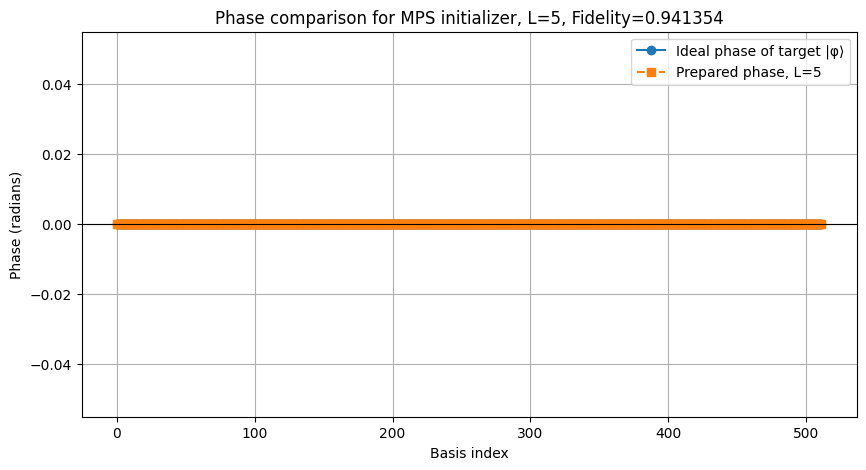

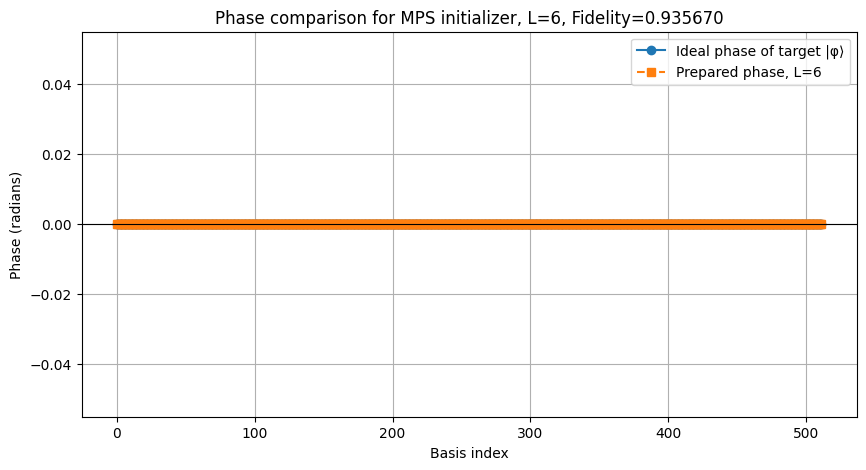

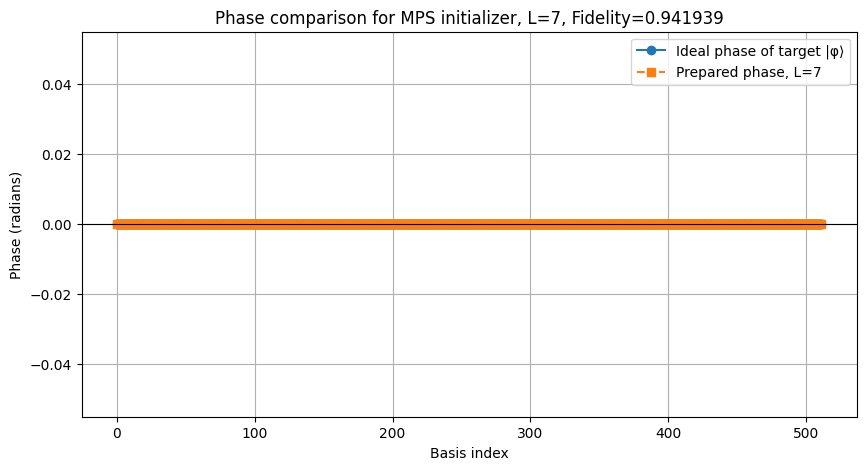

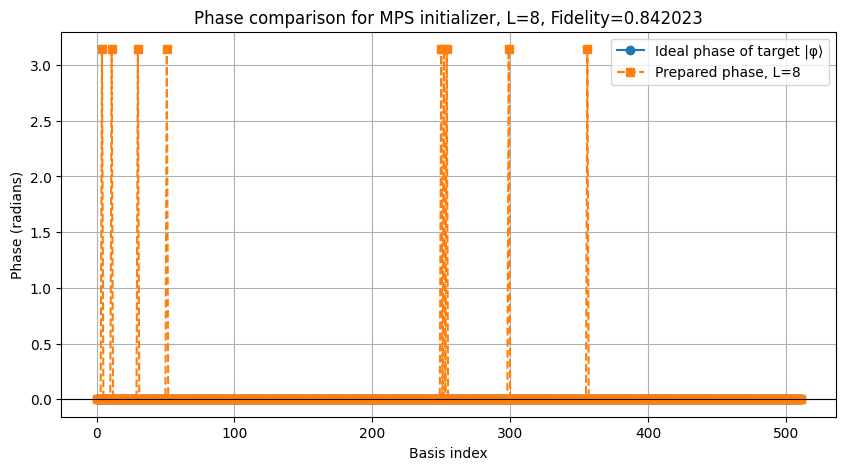

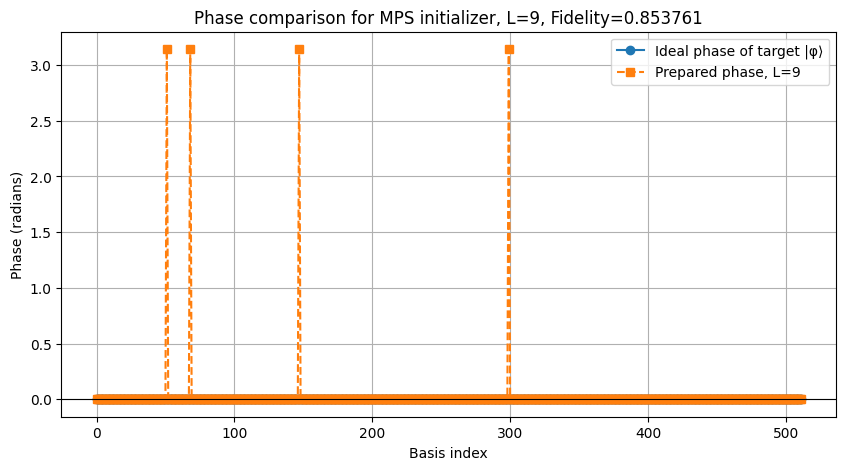

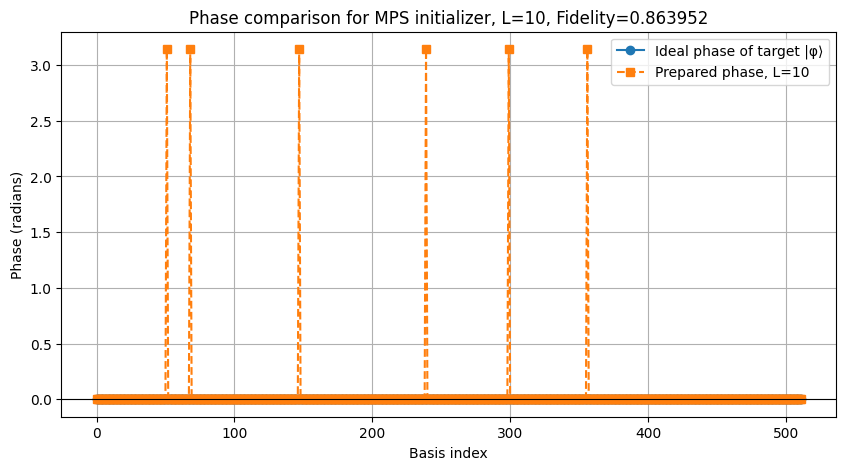

Layer-wise fidelities:
L =  1, Fidelity = 0.92903075
L =  2, Fidelity = 0.92366019
L =  3, Fidelity = 0.96051531
L =  4, Fidelity = 0.90029825
L =  5, Fidelity = 0.94135368
L =  6, Fidelity = 0.93567035
L =  7, Fidelity = 0.94193940
L =  8, Fidelity = 0.84202325
L =  9, Fidelity = 0.85376147
L = 10, Fidelity = 0.86395157


In [15]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_mps_initializer.datatypes import QuantumState
from qiskit.quantum_info import state_fidelity

# ----------------------------
# target state phi
# ----------------------------
phi = np.asarray(phi, dtype=complex)
phi = phi / np.linalg.norm(phi)

N = len(phi)
n = int(np.log2(N))
assert 2**n == N, "Length of phi must be a power of 2."

# simulator
sim = AerSimulator(method="statevector")

# ideal phase once
phases_ideal = np.unwrap(np.angle(phi))

# store fidelities too, just for printing
fidelities = []

# ----------------------------
# plot phase for layers 1 to 10
# ----------------------------
for L in range(1, 11):
    # build MPS initializer
    phi_state = QuantumState.from_dense_data(data=phi, normalize=False)
    U_phi = phi_state.generate_mps_initializer_circuit(number_of_layers=L)

    # prepare circuit
    qc = QuantumCircuit(n)
    qc.append(U_phi, range(n))
    qc.save_statevector()

    # simulate
    result = sim.run(transpile(qc, sim)).result()
    vec_sim = np.array(result.get_statevector(qc), dtype=complex)

    # fidelity
    F = state_fidelity(vec_sim, phi)
    fidelities.append(F)

    # align global phase
    global_phase = np.angle(np.vdot(phi, vec_sim))
    vec_sim_aligned = vec_sim * np.exp(-1j * global_phase)

    # simulated phase
    phases_sim = np.unwrap(np.angle(vec_sim_aligned))

    # phase plot
    plt.figure(figsize=(10, 5))
    plt.plot(range(N), phases_ideal, 'o-', label="Ideal phase of target |φ⟩")
    plt.plot(range(N), phases_sim, 's--', label=f"Prepared phase, L={L}")
    plt.axhline(0, color='black', linewidth=0.8)
    plt.xlabel("Basis index")
    plt.ylabel("Phase (radians)")
    plt.title(f"Phase comparison for MPS initializer, L={L}, Fidelity={F:.6f}")
    plt.legend()
    plt.grid(True)
    plt.show()

# print fidelity summary
print("Layer-wise fidelities:")
for L, F in zip(range(1, 11), fidelities):
    print(f"L = {L:2d}, Fidelity = {F:.8f}")

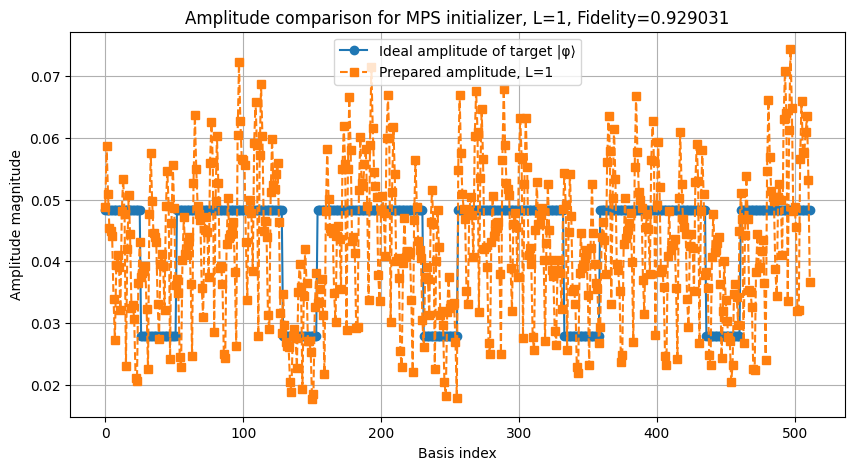

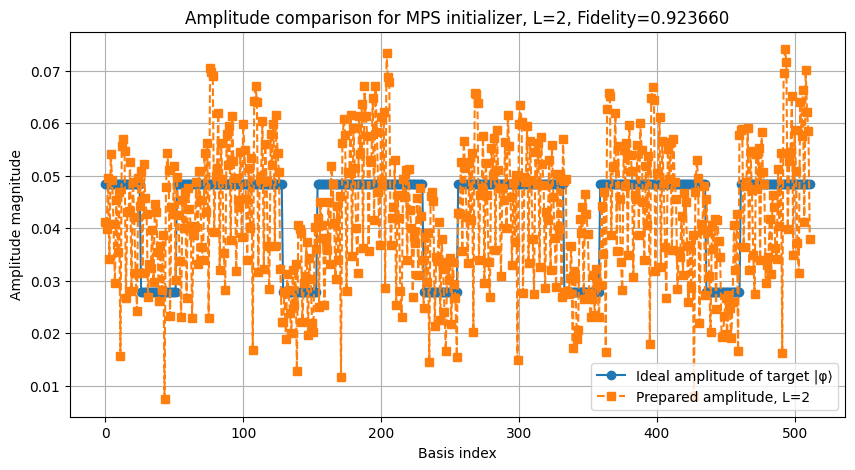

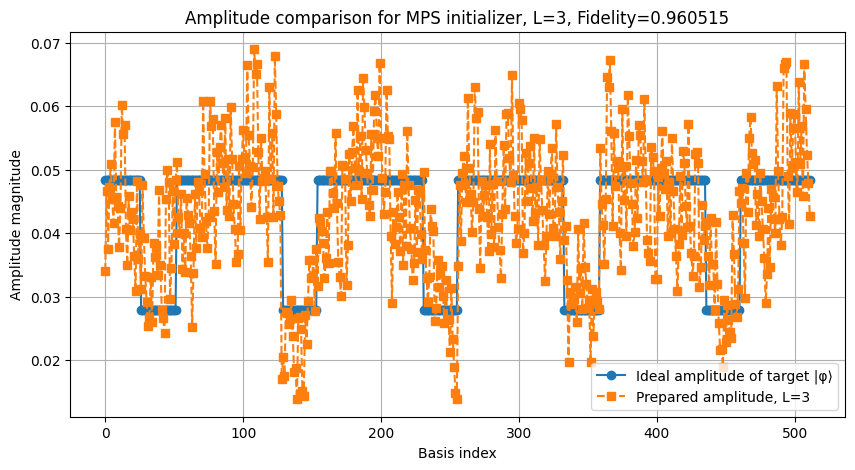

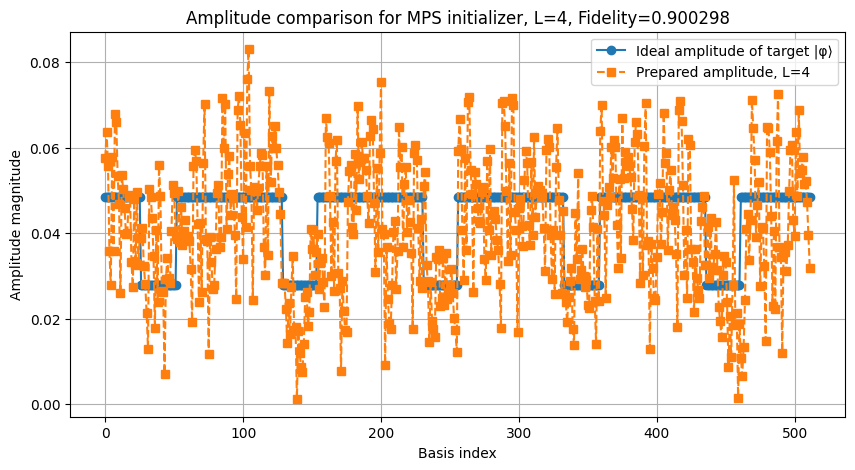

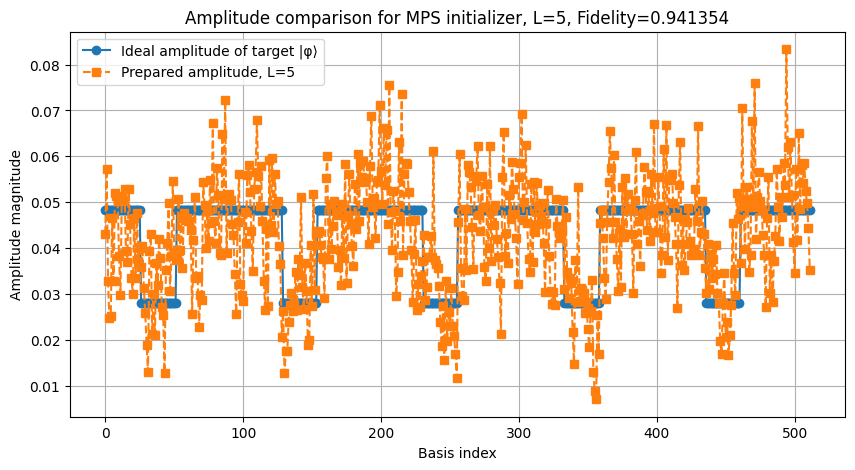

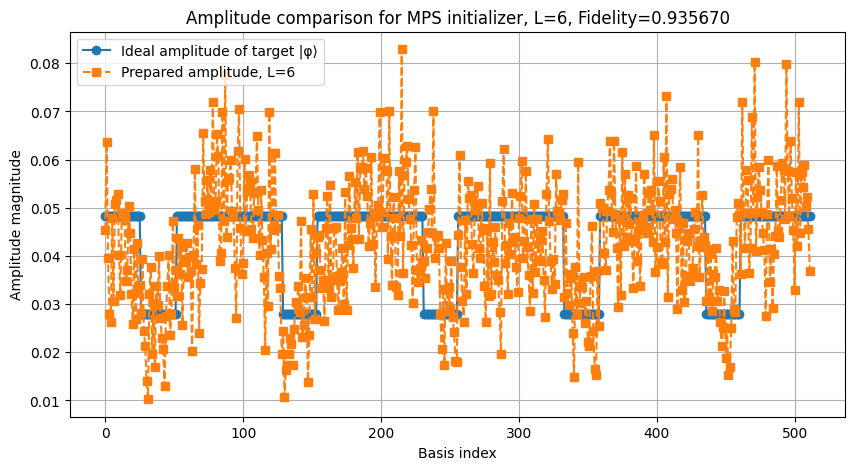

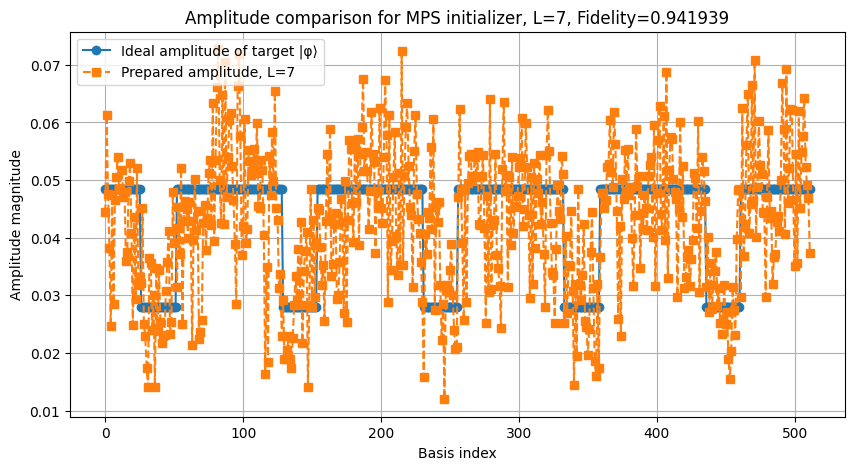

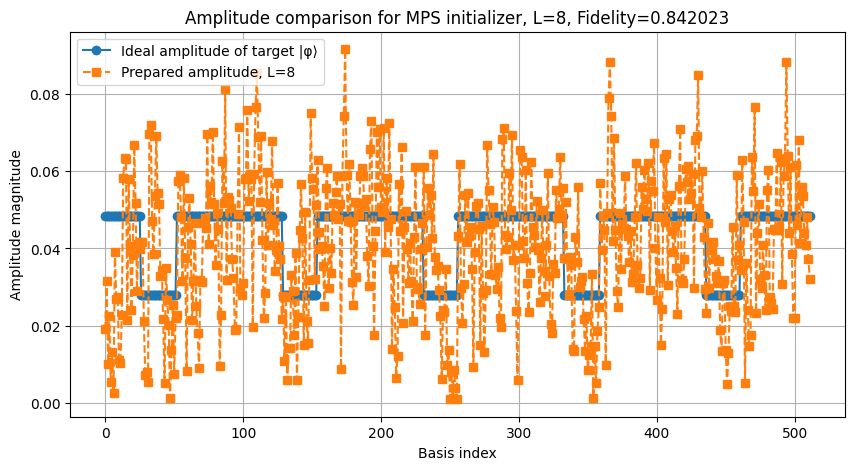

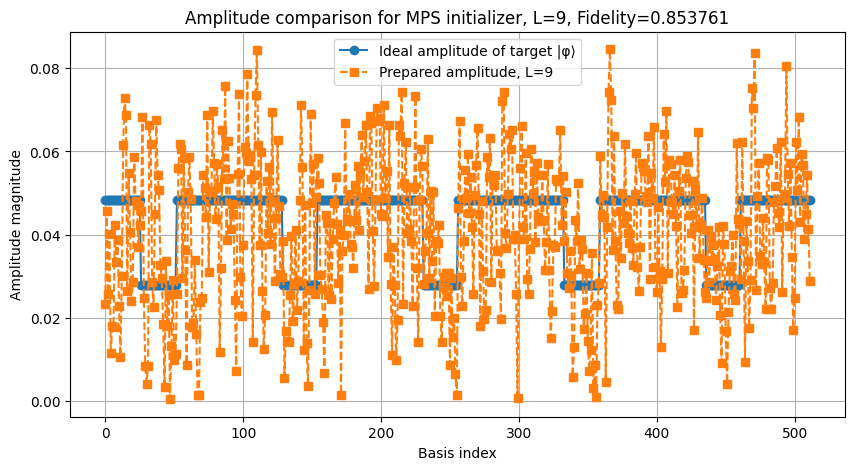

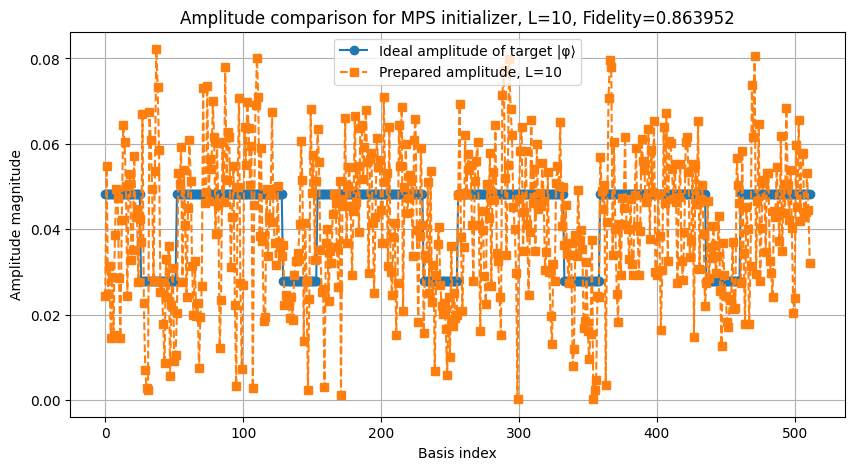

Layer-wise fidelities:
L =  1, Fidelity = 0.92903075
L =  2, Fidelity = 0.92366019
L =  3, Fidelity = 0.96051531
L =  4, Fidelity = 0.90029825
L =  5, Fidelity = 0.94135368
L =  6, Fidelity = 0.93567035
L =  7, Fidelity = 0.94193940
L =  8, Fidelity = 0.84202325
L =  9, Fidelity = 0.85376147
L = 10, Fidelity = 0.86395157


In [17]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_mps_initializer.datatypes import QuantumState
from qiskit.quantum_info import state_fidelity

# ----------------------------
# target state phi
# ----------------------------
phi = np.asarray(phi, dtype=complex)
phi = phi / np.linalg.norm(phi)

N = len(phi)
n = int(np.log2(N))
assert 2**n == N, "Length of phi must be a power of 2."

# simulator
sim = AerSimulator(method="statevector")

fidelities = []

for L in range(1, 11):
    # build MPS initializer
    phi_state = QuantumState.from_dense_data(data=phi, normalize=False)
    U_phi = phi_state.generate_mps_initializer_circuit(number_of_layers=L)

    # prepare circuit
    qc = QuantumCircuit(n)
    qc.append(U_phi, range(n))
    qc.save_statevector()

    # simulate
    result = sim.run(transpile(qc, sim)).result()
    vec_sim = np.array(result.get_statevector(qc), dtype=complex)

    # fidelity
    F = state_fidelity(vec_sim, phi)
    fidelities.append(F)

    # global phase alignment
    global_phase = np.angle(np.vdot(phi, vec_sim))
    vec_sim_aligned = vec_sim * np.exp(-1j * global_phase)

    # amplitudes
    amps_ideal = np.abs(phi)
    amps_sim = np.abs(vec_sim_aligned)

    # amplitude plot
    plt.figure(figsize=(10, 5))
    plt.plot(range(N), amps_ideal, 'o-', label="Ideal amplitude of target |φ⟩")
    plt.plot(range(N), amps_sim, 's--', label=f"Prepared amplitude, L={L}")
    plt.xlabel("Basis index")
    plt.ylabel("Amplitude magnitude")
    plt.title(f"Amplitude comparison for MPS initializer, L={L}, Fidelity={F:.6f}")
    plt.legend()
    plt.grid(True)
    plt.show()

print("Layer-wise fidelities:")
for L, F in zip(range(1, 11), fidelities):
    print(f"L = {L:2d}, Fidelity = {F:.8f}")